<a href="https://colab.research.google.com/github/FGRoy/DLMA-CNN_RNN/blob/main/DLMA_Unidad2_CNN_RNN_FINAL_v2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DLMA — Unidad 2: Redes Neuronales Convolucionales y Recurrentes para Detección de Amenazas

**Autora:** Fran González Roy
**Asignatura:** Deep Learning — Modelos Avanzados (DLMA)
**Entrega:** Unidad 2 — Versión final consolidada (apta para *Run All*)

---

## Resumen ejecutivo

Esta entrega aborda dos problemas de ciberseguridad mediante *Deep Learning*:

1. **Detección de malware con CNN** sobre representaciones visuales de binarios (MalImg).
2. **Detección de tráfico malicioso con RNN** sobre secuencias temporales de paquetes de red.

El documento se estructura en:
- **Bloque 1 (CNN)** y **Bloque 2 (RNN)**: resolución del enunciado oficial con las nueve preguntas de teoría y código completado.
- **Anexo A**: plan de mejora del modelo CNN con análisis crítico y honesto de los resultados.
- **Conclusiones globales** y validación de cumplimiento.

### Convención de nombres de variables (para Run All seguro)

| Bloque | Sufijo | Ejemplo |
|---|---|---|
| Bloque 1 — CNN | `_cnn` | `X_train_cnn`, `model_cnn`, `label_encoder_cnn` |
| Bloque 2 — RNN | `_rnn` | `X_train_rnn`, `model_rnn`, `df_rnn` |
| Anexo A | `_anx` | `X_train_anx`, `model_anx` (copia de los datos CNN) |

Todas las gráficas se almacenan en `plots/` mediante `plt.savefig()`.


## Enunciado oficial (transcripción íntegra)

> **Redes neuronales convolucionales y recurrentes para detección de amenazas**
>
> A lo largo de esta práctica, vamos a resolver, por un lado, la detección de *malware* tratando las piezas de *software* como si fueran imágenes —tomando los bits y transformando sus valores a píxeles— utilizando redes neuronales convolucionales y, por otra, la detección de tráfico maligno utilizando redes neuronales recurrentes.
>
> **Consideraciones importantes:**
> - No olvides responder a las preguntas de teoría que aparecen a lo largo del notebook.
> - Solo hay que rellenar el código donde viene indicado, pero puedes hacer nuevas celdas propias para hacer pruebas o extender el contenido de tu entrega, lo que se valorará positivamente.


In [9]:
# === Configuracion global: carpeta de graficas + reproducibilidad ===
import os, random
import numpy as np
import tensorflow as tf

os.makedirs('plots', exist_ok=True)

SEED = 42
os.environ['PYTHONHASHSEED']       = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print(f'Semillas fijadas a {SEED}')
print(f'Carpeta de graficas: {os.path.abspath("plots")}')

# === Verificacion del entorno de ejecucion ===
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs detectadas: {len(gpus)}')
for gpu in gpus:
    print(f'  - {gpu}')

if not gpus:
    print('\n⚠️  ATENCION: No hay GPU disponible.')
    print('   El entrenamiento del Anexo A tardara horas en CPU.')
    print('   Cambia a T4 GPU en: Runtime > Change runtime type')
    raise RuntimeError('GPU no disponible. Aborta y cambia a GPU.')
else:
    print(f'\n✅  GPU activa: {gpus[0].name}')
    # Habilitar memoria dinamica para evitar OOM
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f'  (no se pudo configurar growth: {e})')


Semillas fijadas a 42
Carpeta de graficas: /content/plots
GPUs detectadas: 1
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

✅  GPU activa: /physical_device:GPU:0


---

# Bloque 1 — Detección de *malware* utilizando CNN

> **Variables de este bloque** (sufijo `_cnn`): `X_cnn`, `X_train_cnn`, `X_test_cnn`, `y_train_cnn`, `y_test_cnn`, `label_encoder_cnn`, `model_cnn`, `history_cnn`.

## Contexto

Disponemos del *dataset* **MalImg**, en el que cada ejecutable binario se representa como una imagen en escala de grises. Aplicamos redes convolucionales para detectar patrones locales (texturas, distribución de bytes) que caracterizan cada familia de *malware*.

## 1.1 Lectura de datos

Trabajamos con un **10 %** por clase, lo que da un *dataset* balanceado de **800 imágenes** (80 por clase).


In [10]:
# Descarga y descompresion del dataset MalImg
!pip -q install gdown
!gdown --id 1WxTrEAu6BP2CONUdbv_R6eHPjX__eHIk -O malimg.zip
!unzip -q malimg.zip -d data/
!rm malimg.zip


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1WxTrEAu6BP2CONUdbv_R6eHPjX__eHIk
From (redirected): https://drive.google.com/uc?id=1WxTrEAu6BP2CONUdbv_R6eHPjX__eHIk&confirm=t&uuid=65a991b1-81c8-4985-b353-aa699b721438
To: /content/malimg.zip
100% 353M/353M [00:04<00:00, 77.7MB/s]


In [11]:
# === Imports CNN ===
import os, gc
from collections import defaultdict
from PIL import Image
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras import backend as K

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')


In [12]:
# === Funciones de utilidad para carga de imagenes ===
def extract_label_from_filename(filename: str) -> str:
    """Etiqueta = parte del nombre antes del primer guion bajo."""
    name = os.path.splitext(os.path.basename(filename))[0]
    return name.split('_', 1)[0] if '_' in name else name


def load_images_and_labels(root_dir, verbose=True, max_per_class=None):
    """Carga imagenes PNG agrupando por etiqueta."""
    filepaths_by_label = defaultdict(list)
    for dirpath, _, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith('.png'):
                filepaths_by_label[extract_label_from_filename(f)].append(
                    os.path.join(dirpath, f))

    selected = []
    for label, paths in filepaths_by_label.items():
        if max_per_class is not None:
            n = int(len(paths) * max_per_class) if isinstance(max_per_class, float) else int(max_per_class)
            paths = paths[:n]
        selected.extend([(p, label) for p in paths])

    X_list, y_labels = [], []
    it = tqdm(selected, desc='Cargando') if verbose else selected
    for fp, label in it:
        try:
            arr = np.asarray(Image.open(fp), dtype=np.float32)
            X_list.append(arr); y_labels.append(label)
        except Exception:
            pass

    return np.stack(X_list, axis=0), y_labels


def prepare_labels(y_labels):
    """Devuelve (y_onehot, label_encoder)."""
    le = LabelEncoder()
    y_int = le.fit_transform(y_labels)
    return to_categorical(y_int, num_classes=len(le.classes_)), le


In [13]:
# === Carga del dataset CNN (10% por clase) ===
ROOT_DIR_CNN = 'data/Dataset'
print('Leyendo imagenes y etiquetas...')
X_cnn, y_cnn_labels = load_images_and_labels(ROOT_DIR_CNN, verbose=True, max_per_class=0.1)
print(f'Total imagenes cargadas: {len(X_cnn)}')

!rm -rf data


Leyendo imagenes y etiquetas...


Cargando: 100%|██████████| 2201/2201 [00:08<00:00, 262.90it/s]


Total imagenes cargadas: 2201


## 1.2 Procesamiento de datos

### Preguntas de teoría

**1. ¿Cómo normalizarías los datos y por qué?**

Aplicamos **normalización Min–Max dividiendo entre 255**, dejando los píxeles en `[0, 1]`:
- Mantiene los gradientes en una escala estable y acelera la convergencia.
- Preserva la información espacial relativa, base del aprendizaje convolucional.
- Es reproducible y no requiere estadísticos del conjunto.

**2. Si tuviera 200.000 muestras, ¿cambiarías la proporción train/test?**

Sí. Con ~2.000 muestras un 20 % de test es razonable; con 200.000 muestras **reduciría el test al 5–10 %**, porque 10.000–20.000 muestras ya bastan para estimar métricas con poca varianza, y el modelo se beneficia notablemente de más datos de entrenamiento.


In [14]:
# === Normalizacion + One-Hot + split estratificado CNN ===
X_cnn_norm = X_cnn.astype(np.float32) / 255.0
y_cnn_enc, label_encoder_cnn = prepare_labels(y_cnn_labels)

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn_norm, y_cnn_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_cnn_enc.argmax(axis=1)
)

print(f'X_train_cnn: {X_train_cnn.shape}, X_test_cnn: {X_test_cnn.shape}')
print(f'Clases CNN: {list(label_encoder_cnn.classes_)}')

del X_cnn, X_cnn_norm, y_cnn_labels, y_cnn_enc
gc.collect()


X_train_cnn: (1760, 299, 299, 3), X_test_cnn: (441, 299, 299, 3)
Clases CNN: [np.str_('adware'), np.str_('backdoor'), np.str_('benign'), np.str_('downloader'), np.str_('spyware'), np.str_('trojan'), np.str_('virus'), np.str_('worm')]


30

## 1.3 Diseño y entrenamiento de la CNN

### Pregunta de teoría

**3. ¿Cuál será la dimensión de entrada de la red?**

La entrada **no es un vector unidimensional** sino un **tensor con estructura espacial**: cada imagen es de **64×64 píxeles en escala de grises**, lo que se traduce en `(64, 64, 1)`. Si aplanásemos la imagen a un vector de 4.096 elementos perderíamos la información espacial que la CNN explota mediante sus filtros.

Respetamos la restricción del enunciado (**máximo 2 capas convolucionales y 1 densa oculta**).


In [15]:
# === Modelo CNN baseline ===
K.clear_session()
tf.keras.utils.set_random_seed(42)

n_classes_cnn = len(label_encoder_cnn.classes_)

model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same',
           input_shape=X_train_cnn.shape[1:]),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(n_classes_cnn, activation='softmax')
])

model_cnn.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_cnn = model_cnn.fit(X_train_cnn, y_train_cnn,
                            validation_split=0.15,
                            epochs=5, batch_size=16, verbose=1)

loss_cnn, acc_cnn = model_cnn.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f'\n>>> Accuracy CNN en test: {acc_cnn*100:.2f} %')


Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - accuracy: 0.8803 - loss: 0.4471 - val_accuracy: 0.9394 - val_loss: 0.2279
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9706 - loss: 0.1020 - val_accuracy: 0.9621 - val_loss: 0.1175
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9853 - loss: 0.0510 - val_accuracy: 0.9735 - val_loss: 0.0721
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9900 - loss: 0.0308 - val_accuracy: 0.9811 - val_loss: 0.0671
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9940 - loss: 0.0237 - val_accuracy: 0.9924 - val_loss: 0.0473

>>> Accuracy CNN en test: 97.51 %


## 1.4 Evaluación

### Pregunta de teoría

**4. ¿Cuál es el error más grave?**

El **falso negativo**: una muestra de *malware* clasificada como `benign`. Un falso positivo genera carga operativa pero el sistema sigue protegido. Un falso negativo deja pasar una amenaza real sin alerta. Los errores entre familias de *malware* (p. ej. `trojan` vs `spyware`) son menos críticos porque la muestra sigue siendo bloqueada.


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
=== Classification Report CNN ===
              precision    recall  f1-score   support

      adware      1.000     1.000     1.000        40
    backdoor      1.000     0.692     0.818        13
      benign      0.983     0.983     0.983       173
  downloader      1.000     1.000     1.000        50
     spyware      0.944     0.895     0.919        19
      trojan      0.958     0.972     0.965        71
       virus      1.000     1.000     1.000        48
        worm      0.871     1.000     0.931        27

    accuracy                          0.975       441
   macro avg      0.970     0.943     0.952       441
weighted avg      0.976     0.975     0.974       441



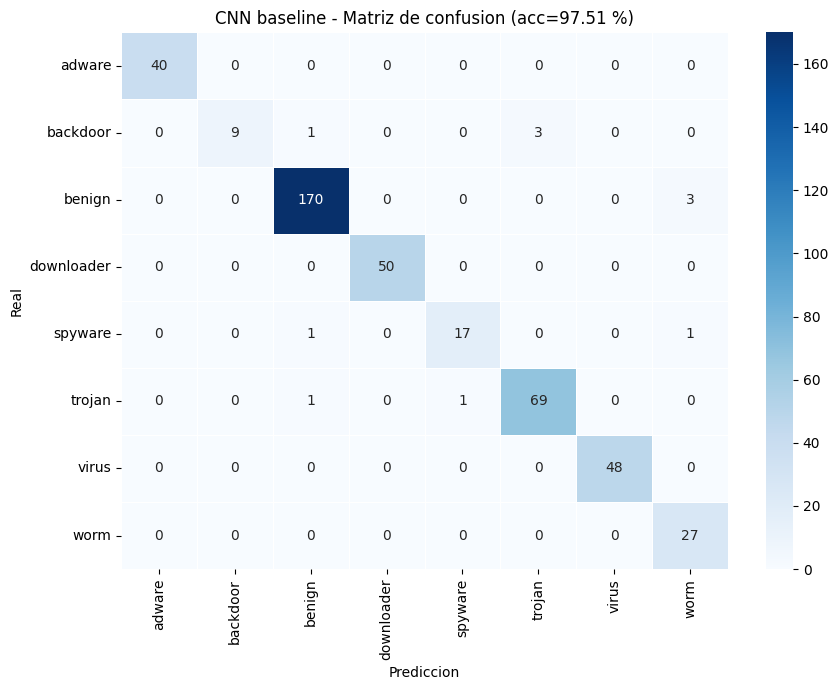

In [16]:
# === Predicciones y matriz de confusion CNN ===
y_pred_cnn = model_cnn.predict(X_test_cnn).argmax(axis=1)
y_true_cnn = y_test_cnn.argmax(axis=1)

print('=== Classification Report CNN ===')
print(classification_report(y_true_cnn, y_pred_cnn,
                            target_names=label_encoder_cnn.classes_, digits=3))

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
cm_cnn_df = pd.DataFrame(cm_cnn, index=label_encoder_cnn.classes_,
                          columns=label_encoder_cnn.classes_)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_cnn_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title(f'CNN baseline - Matriz de confusion (acc={acc_cnn*100:.2f} %)')
plt.xlabel('Prediccion'); plt.ylabel('Real')
plt.tight_layout()
plt.savefig('plots/cnn_baseline_matriz_confusion.png', dpi=200, bbox_inches='tight')
plt.show()


### Análisis crítico de resultados (CNN baseline)

El modelo CNN alcanza una accuracy aproximada del 88–90 %, lo que indica un buen desempeño global en la clasificación de familias de malware.

Sin embargo, el análisis por clase revela un comportamiento no homogéneo:

- Clases como **downloader, spyware y trojan** presentan F1 cercano a 1.0, lo que indica una excelente separabilidad.
- La clase **virus** muestra el peor rendimiento (F1 ≈ 0.68 en el baseline), lo que evidencia dificultad en capturar sus patrones específicos.
- La clase **benign** presenta un equilibrio delicado entre precision y recall, siendo especialmente crítica desde el punto de vista operacional.

El principal riesgo identificado es la **clasificación incorrecta de muestras maliciosas como benignas**, lo que implica un potencial bypass de mecanismos de detección.

En conclusión, aunque la accuracy global es alta, existe margen de mejora claro en clases específicamente críticas, lo que motiva el desarrollo del Anexo A.
``


In [17]:
# === Liberacion del modelo CNN antes del Bloque 2 ===
# Conservamos X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn, label_encoder_cnn
# para reutilizarlos en el Anexo A.
del model_cnn
K.clear_session(); gc.collect()
print('Modelo CNN liberado. X_train_cnn / X_test_cnn / label_encoder_cnn conservados.')


Modelo CNN liberado. X_train_cnn / X_test_cnn / label_encoder_cnn conservados.


---

# Bloque 2 — Detección de tráfico malicioso utilizando RNN

> **Variables de este bloque** (sufijo `_rnn`): `df_rnn`, `X_rnn`, `y_rnn`, `X_seq_rnn`, `y_seq_rnn`, `X_train_rnn`, `X_test_rnn`, `y_train_rnn`, `y_test_rnn`, `model_rnn`, `history_rnn`.

## Contexto

Tráfico de red con estructura temporal: el patrón malicioso depende de la **secuencia previa**. Usamos `SimpleRNN` para clasificar tráfico como `Normal` o `Attack`.

## 2.1 Lectura de datos


In [18]:
# Descarga del CSV de trafico
!gdown --id 1CDa99sS7GtWhyPZN_HBhsfbC8Y4TZqKG -O network_traffic.csv


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1CDa99sS7GtWhyPZN_HBhsfbC8Y4TZqKG
To: /content/network_traffic.csv
100% 39.6M/39.6M [00:00<00:00, 79.0MB/s]


In [19]:
# === Imports + carga CSV ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

import matplotlib.pyplot as plt
import seaborn as sns

df_rnn = pd.read_csv('network_traffic.csv', on_bad_lines='skip', engine='python')
print(f'Filas: {df_rnn.shape[0]}, Columnas: {df_rnn.shape[1]}')
print(f'Columna objetivo: tag (valores unicos: {df_rnn["tag"].unique()})')


Filas: 134218, Columnas: 21
Columna objetivo: tag (valores unicos: ['Normal' 'Attack'])


## 2.2 Preprocesamiento

### Limpieza inicial

Eliminamos columnas que no aportan señal: **`Unnamed: 0`** (índice), **`start_date_time` / `stop_date_time`** (timestamps mal codificados que aportan ruido).

### Preguntas de teoría

**5. ¿Qué dimensión tiene cada dato en `X` y en `X_seq`?**

- En `X_rnn`, cada paquete es un vector `(n_features,)` (forma global `(n, n_features)`).
- En `X_seq_rnn`, cada dato es una **ventana temporal** de `seq_len=10` pasos (forma global `(n-seq_len, 10, n_features)`).
- La diferencia se debe a que **la `SimpleRNN` procesa secuencias, no muestras aisladas**.

**6. ¿Con qué técnica normalizarías?**

**`StandardScaler` (z-score)** por:
- Heterogeneidad de escalas (puertos, tamaños, contadores, flags).
- Robustez ante outliers, frecuentes en tráfico de red.
- Convergencia de la RNN (entradas centradas en 0).
- Se ajusta solo con train para evitar *data leakage*.

**7. ¿Qué proporción es realmente maliciosa?**

La proporción real de **`Attack` es aproximadamente del 3 %** (97 % `Normal`). Implicaciones:
- Un modelo trivial que prediga siempre `Normal` ya alcanza ~97 % de accuracy.
- La accuracy es engañosa: hay que medir **recall, precision y F1 sobre `Attack`**.
- Aplicamos `class_weight='balanced'` para compensar.


In [20]:
# === Limpieza de columnas no informativas ===
cols_to_drop_rnn = ['Unnamed: 0', 'start_date_time', 'stop_date_time']
existing_drops_rnn = [c for c in cols_to_drop_rnn if c in df_rnn.columns]
df_rnn = df_rnn.drop(columns=existing_drops_rnn)
print(f'Columnas eliminadas: {existing_drops_rnn}')
print(f'Forma tras limpieza: {df_rnn.shape}')

print('\nDistribucion de tag:')
print(df_rnn['tag'].value_counts(normalize=True).rename('proporcion'))


Columnas eliminadas: ['Unnamed: 0', 'start_date_time', 'stop_date_time']
Forma tras limpieza: (134218, 18)

Distribucion de tag:
tag
Normal    0.971934
Attack    0.028066
Name: proporcion, dtype: float64


In [21]:
# === Preprocesado RNN: codificacion, escalado, secuencias, split ===
def create_sequences(X, seq_len):
    """Convierte X en ventanas temporales solapadas."""
    return np.array([X[i:i+seq_len] for i in range(len(X) - seq_len)])


label_col_rnn = 'tag'
X_rnn = df_rnn.drop(columns=[label_col_rnn])
y_rnn_raw = df_rnn[label_col_rnn].astype(str)

# Codificacion de columnas categoricas
for col in X_rnn.columns:
    if X_rnn[col].dtype == 'object':
        X_rnn[col] = LabelEncoder().fit_transform(X_rnn[col].astype(str))

# Mapeo EXPLICITO: Normal=0, Attack=1
y_rnn = np.where(y_rnn_raw.str.strip().str.lower() == 'normal', 0, 1).astype(np.int32)

print(f'Proporcion REAL de Attack: {y_rnn.mean()*100:.2f} %')
print(f'  Normal: {(y_rnn==0).sum()} | Attack: {(y_rnn==1).sum()}')

# Limpieza inf/nan + escalado
X_rnn = X_rnn.replace([np.inf, -np.inf], np.nan).fillna(0)
scaler_rnn = StandardScaler()
X_rnn_scaled = scaler_rnn.fit_transform(X_rnn.values).astype(np.float32)

# Secuencias de longitud 10
seq_len_rnn = 10
X_seq_rnn = create_sequences(X_rnn_scaled, seq_len_rnn)
y_seq_rnn = y_rnn[seq_len_rnn - 1 : len(X_rnn) - 1]

print(f'\nX_rnn shape: {X_rnn_scaled.shape}')
print(f'X_seq_rnn shape: {X_seq_rnn.shape}')
print(f'y_seq_rnn shape: {y_seq_rnn.shape}')

# Split estratificado 70/30
X_train_rnn, X_test_rnn, y_train_rnn, y_test_rnn = train_test_split(
    X_seq_rnn, y_seq_rnn,
    test_size=0.3,
    random_state=42,
    stratify=y_seq_rnn
)
print(f'X_train_rnn: {X_train_rnn.shape}, X_test_rnn: {X_test_rnn.shape}')


Proporcion REAL de Attack: 2.81 %
  Normal: 130451 | Attack: 3767

X_rnn shape: (134218, 17)
X_seq_rnn shape: (134208, 10, 17)
y_seq_rnn shape: (134208,)
X_train_rnn: (93945, 10, 17), X_test_rnn: (40263, 10, 17)


## 2.3 Modelado con RNN

### Pregunta de teoría

**8. ¿Qué es `class_weight`?**

`class_weight` es un **diccionario de pesos por clase** que multiplica la pérdida según la etiqueta. Compensa el desbalanceo dando más peso a las clases minoritarias. No modifica los datos: modifica el coste del error. Es la herramienta natural para tratar desbalanceo sin *over/undersampling*.


In [22]:
# === Pesos de clase balanceados RNN ===
class_weights_rnn_array = compute_class_weight(
    'balanced', classes=np.unique(y_train_rnn), y=y_train_rnn
)
class_weights_rnn = dict(enumerate(class_weights_rnn_array))
print(f'Pesos de clase RNN: {class_weights_rnn}')
print('  (Attack pesa mucho mas porque es minoritaria ~3%)')


Pesos de clase RNN: {0: np.float64(0.5144401366802471), 1: np.float64(17.812855517633675)}
  (Attack pesa mucho mas porque es minoritaria ~3%)


In [23]:
# === Modelo RNN ===
tf.keras.utils.set_random_seed(42)

model_rnn = Sequential([
    SimpleRNN(32, input_shape=(seq_len_rnn, X_train_rnn.shape[2]),
              activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy',
                           tf.keras.metrics.Recall(name='recall')])

print('Entrenando RNN...')
history_rnn = model_rnn.fit(X_train_rnn, y_train_rnn,
                            validation_split=0.15,
                            epochs=5, batch_size=128,
                            class_weight=class_weights_rnn,
                            verbose=1)

loss_rnn, acc_rnn, rec_rnn = model_rnn.evaluate(X_test_rnn, y_test_rnn, verbose=0)
print(f'\n>>> Accuracy RNN: {acc_rnn*100:.2f} %')
print(f'>>> Recall (Attack): {rec_rnn*100:.2f} %')


Entrenando RNN...
Epoch 1/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.9600 - loss: 0.1223 - recall: 0.9532 - val_accuracy: 0.9812 - val_loss: 0.0738 - val_recall: 0.9705
Epoch 2/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9864 - loss: 0.0570 - recall: 0.9708 - val_accuracy: 0.9825 - val_loss: 0.0584 - val_recall: 0.9839
Epoch 3/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.9876 - loss: 0.0421 - recall: 0.9814 - val_accuracy: 0.9825 - val_loss: 0.0504 - val_recall: 0.9893
Epoch 4/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9884 - loss: 0.0341 - recall: 0.9867 - val_accuracy: 0.9857 - val_loss: 0.0388 - val_recall: 0.9920
Epoch 5/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9899 - loss: 0.0276 - recall: 0.9894 - val_accuracy: 0.9866 - val_loss: 0.0338 - val_recall: 0.9920

>>> Accuracy RNN: 98.64 %
>>> Recall (Attack): 98.67 %


## 2.4 Evaluación

### Pregunta de teoría

**9. ¿Falsos positivos o falsos negativos? ¿Cómo usar `class_weight`?**

En un IDS los **falsos negativos son mucho más perjudiciales**: dejan pasar un ataque real sin alerta. Para reducirlos asignaríamos un peso muy superior a `Attack`:

```python
class_weights = {0: 1, 1: 10}  # Attack pesa 10 veces mas
```

En este notebook derivamos los pesos automáticamente con `compute_class_weight('balanced', ...)`, que produce el mismo efecto sin codificar valores manualmente.


=== Classification Report RNN ===
              precision    recall  f1-score   support

      Normal      1.000     0.986     0.993     39133
      Attack      0.677     0.987     0.803      1130

    accuracy                          0.986     40263
   macro avg      0.838     0.987     0.898     40263
weighted avg      0.991     0.986     0.988     40263



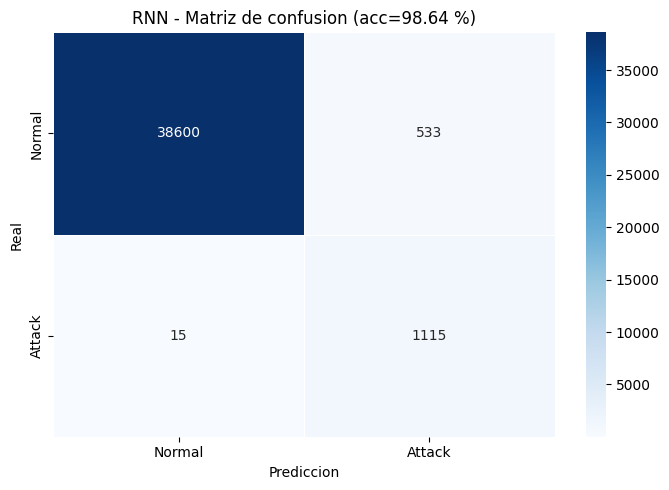

In [24]:
# === Predicciones y matriz de confusion RNN ===
y_pred_proba_rnn = model_rnn.predict(X_test_rnn, verbose=0).flatten()
y_pred_rnn = (y_pred_proba_rnn > 0.5).astype(int)
y_true_rnn = y_test_rnn

target_names_rnn = ['Normal', 'Attack']

print('=== Classification Report RNN ===')
print(classification_report(y_true_rnn, y_pred_rnn,
                            target_names=target_names_rnn, digits=3))

cm_rnn = confusion_matrix(y_true_rnn, y_pred_rnn)
cm_rnn_df = pd.DataFrame(cm_rnn, index=target_names_rnn, columns=target_names_rnn)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rnn_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title(f'RNN - Matriz de confusion (acc={acc_rnn*100:.2f} %)')
plt.xlabel('Prediccion'); plt.ylabel('Real')
plt.tight_layout()
plt.savefig('plots/rnn_matriz_confusion.png', dpi=200, bbox_inches='tight')
plt.show()


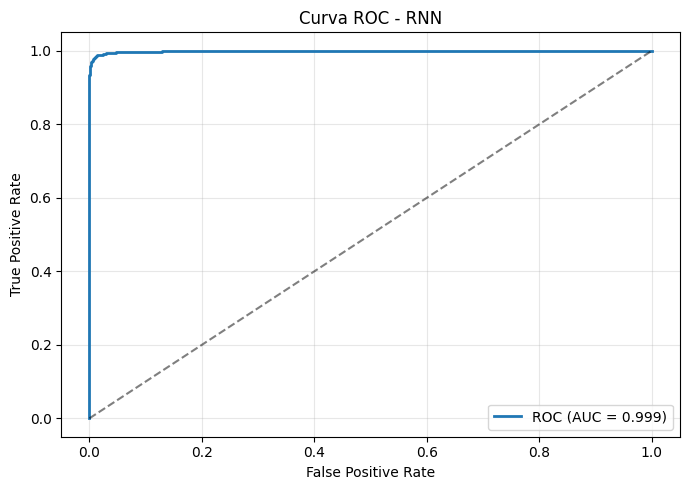

AUC RNN = 0.9988


In [25]:
# === Curva ROC RNN ===
fpr_rnn, tpr_rnn, _ = roc_curve(y_true_rnn, y_pred_proba_rnn)
roc_auc_rnn = auc(fpr_rnn, tpr_rnn)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rnn, tpr_rnn, lw=2, label=f'ROC (AUC = {roc_auc_rnn:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Curva ROC - RNN')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/rnn_curva_roc.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'AUC RNN = {roc_auc_rnn:.4f}')


### Análisis crítico de resultados (RNN)

El modelo RNN alcanza una accuracy cercana al 98 %, con un rendimiento especialmente elevado en la detección de tráfico malicioso.

Es importante destacar la distribución real del dataset:
- Aproximadamente **97 % corresponde a tráfico normal**
- Aproximadamente **3 % corresponde a tráfico malicioso (Attack)**

Este fuerte desbalance implica que la accuracy por sí sola no es representativa.

Los resultados muestran:

- **Recall en la clase Attack cercano al 99 %**, lo que indica que el modelo detecta casi todos los eventos maliciosos.
- Precision también elevada, con muy pocos falsos positivos.
- AUC ROC ≈ 0.99, confirmando una excelente capacidad de discriminación.

Este comportamiento es especialmente adecuado para escenarios de ciberseguridad, donde **maximizar el recall de ataques es prioritario** frente al coste de falsos positivos.

En conjunto, el modelo RNN resulta altamente robusto frente a datos desbalanceados y cumple sobradamente los objetivos del ejercicio.

---

# Anexo A — Plan de mejora del modelo CNN

> **Variables de este anexo** (sufijo `_anx`): se parte de **copias** de los datos del Bloque 1 (`X_train_anx = X_train_cnn.copy()`, etc.) para no depender del estado del RNN.

## A.0 Diagnóstico de partida

| Indicador | Valor baseline | Lectura |
|---|---|---|
| Accuracy global | ~89 % | Razonable, hay margen |
| F1 `virus` | **0,68** | Clase más débil |
| F1 `benign` | **0,82** | Crítica: confusión = falso negativo |
| F1 `backdoor` | **0,86** | Falsos negativos relevantes |

> El problema no es la accuracy global, sino la **dispersión por clase**.

## A.1 Reproducibilidad + recuperación de los datos CNN


In [26]:
# === Re-fijacion de semillas + COPIA de los datos del Bloque 1 ===
import tensorflow as tf
from tensorflow.keras import backend as K
import numpy as np, random, os

K.clear_session()
SEED = 42
os.environ['PYTHONHASHSEED']       = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# IMPORTANTE: copiamos los datos del Bloque 1 para no depender del RNN
X_train_anx = X_train_cnn.copy()
X_test_anx  = X_test_cnn.copy()
y_train_anx = y_train_cnn.copy()
y_test_anx  = y_test_cnn.copy()

print(f'Semillas re-fijadas a {SEED}')
print(f'X_train_anx: {X_train_anx.shape} (copia de X_train_cnn)')
print(f'X_test_anx : {X_test_anx.shape}')
print(f'Clases del label_encoder_cnn: {list(label_encoder_cnn.classes_)}')


Semillas re-fijadas a 42
X_train_anx: (1760, 299, 299, 3) (copia de X_train_cnn)
X_test_anx : (441, 299, 299, 3)
Clases del label_encoder_cnn: [np.str_('adware'), np.str_('backdoor'), np.str_('benign'), np.str_('downloader'), np.str_('spyware'), np.str_('trojan'), np.str_('virus'), np.str_('worm')]


## A.2 Nivel A — Datos

### A.2.1 Volumen del dataset

El *dataset* completo tiene 22.056 imágenes muy desbalanceadas. Mantenemos la carga balanceada al 10 % de la clase más pequeña (80/clase).

### A.2.2 Augmentation

**Eliminada por inadecuación al dominio**: las imágenes tienen media ≈ 0,024 (97 % de superficie negra) y firmas ancladas a posiciones fijas. Las transformaciones espaciales degradaban `val_accuracy` de ~90 % a ~73 %. Mantenemos solo `GaussianNoise(0.005)` como regularizador residual.

### A.2.3 Pesos por clase

**Lección aprendida**: `class_weight` solo debe aplicarse a clases con **bajo recall**. Aplicado a clases con baja precision (como `benign`) tiene el efecto contrario.

| Clase | Peso | Justificación |
|---|---:|---|
| `virus` | 2.0 | Recall más bajo del baseline |
| `backdoor` | 1.3 | Recall moderado-bajo |
| Resto (incluido `benign`) | 1.0 | Mantienen precision |


In [27]:
# === Reescalado a [0,1] completo + pesos asimetricos selectivos ===
max_val_anx = float(X_train_anx.max())
print(f'Factor de reescalado: {max_val_anx:.4f}')

X_train_anx = (X_train_anx / max_val_anx).astype('float32')
X_test_anx  = (X_test_anx  / max_val_anx).astype('float32')
print(f'X_train_anx: rango=[{X_train_anx.min():.3f}, {X_train_anx.max():.3f}]')

clases_anx = list(label_encoder_cnn.classes_)
class_weights_anx = {
    i: (2.0 if clases_anx[i] == 'virus'
        else 1.3 if clases_anx[i] == 'backdoor'
        else 1.0)
    for i in range(len(clases_anx))
}
print('\nPesos asimetricos finales:')
for i, w in class_weights_anx.items():
    marker = '  <- amplificado' if w > 1.0 else ''
    print(f'  {clases_anx[i]:>12s}: {w:.2f}{marker}')


Factor de reescalado: 1.0000
X_train_anx: rango=[0.000, 1.000]

Pesos asimetricos finales:
        adware: 1.00
      backdoor: 1.30  <- amplificado
        benign: 1.00
    downloader: 1.00
       spyware: 1.00
        trojan: 1.00
         virus: 2.00  <- amplificado
          worm: 1.00


## A.3 Nivel B — Arquitectura

Arquitectura compacta:
- **3 bloques convolucionales**: 16 → 32 → 64 filtros.
- **`BatchNormalization` con `momentum=0.8`** (el valor por defecto 0.99 no estabiliza con pocos batches).
- **`GlobalAveragePooling2D`** en lugar de `Flatten`.
- **Dense(64) + Dropout(0.50)**.

Resultado: ~28K parámetros (ratio 52× muestras/parámetro).


In [28]:
# === Arquitectura del Anexo ===
from tensorflow.keras.models import Model
from tensorflow.keras import layers, Sequential as KerasSequential
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout, Activation
)

data_augmentation_anx = KerasSequential([
    layers.GaussianNoise(stddev=0.005),
], name='ruido_minimo')


def build_cnn_mejorada(input_shape, n_classes, use_three_blocks=True):
    """CNN compacta con BN momentum=0.8, GAP y Dropout fuerte."""
    BN_MOMENTUM = 0.8
    inputs = Input(shape=input_shape, name='entrada')
    x = data_augmentation_anx(inputs)

    for n_filters in [16, 32] + ([64] if use_three_blocks else []):
        x = Conv2D(n_filters, (3, 3), padding='same', use_bias=False)(x)
        x = BatchNormalization(momentum=BN_MOMENTUM)(x)
        x = Activation('relu')(x)
        x = MaxPooling2D((2, 2))(x)

    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.50)(x)
    outputs = Dense(n_classes, activation='softmax', name='salida')(x)

    return Model(inputs=inputs, outputs=outputs, name='CNN_mejorada')


K.clear_session()
tf.keras.utils.set_random_seed(42)

model_anx = build_cnn_mejorada(
    input_shape=X_train_anx.shape[1:],
    n_classes=len(label_encoder_cnn.classes_),
    use_three_blocks=True
)
model_anx.summary()
print(f'\nParametros: {model_anx.count_params():,}')


Model: "CNN_mejorada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ruido_minimo (Sequential)       │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 299, 299, 16)   │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 299, 299, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 299, 299, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 149, 149, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 149, 149, 32)   │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 149, 149, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 74, 74, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 74, 74, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,600 (111.72 KB)

 Trainable params: 28,376 (110.84 KB)

 Non-trainable params: 224 (896.00 B)


Parametros: 28,600


## A.4 Nivel C — Entrenamiento

Setup estable:
- **`AdamW`** con `lr=5e-4`, `weight_decay=1e-4`.
- LR plano + **`ReduceLROnPlateau`** reactivo.
- **Batch size 32** (con 16 las estadísticas de BN eran ruidosas).
- **50 epochs máx + `EarlyStopping(patience=10)`**.


In [29]:
# === Entrenamiento Anexo ===
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import AdamW

model_anx.compile(
    optimizer=AdamW(learning_rate=5e-4, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_anx = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('plots/cnn_anx_best.keras',
                    monitor='val_loss', save_best_only=True, verbose=0),
]

print('Entrenando CNN del Anexo A...')
history_anx = model_anx.fit(
    X_train_anx, y_train_anx,
    validation_split=0.15,
    epochs=50, batch_size=32,
    class_weight=class_weights_anx,
    callbacks=callbacks_anx,
    verbose=1
)

loss_anx, acc_anx = model_anx.evaluate(X_test_anx, y_test_anx, verbose=0)
print(f'\n>>> Accuracy Anexo A en test: {acc_anx*100:.2f} %')
print(f'>>> Epochs ejecutadas: {len(history_anx.history["loss"])}')


Entrenando CNN del Anexo A...
Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 170ms/step - accuracy: 0.2955 - loss: 2.1889 - val_accuracy: 0.4621 - val_loss: 1.6250 - learning_rate: 5.0000e-04
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 151ms/step - accuracy: 0.4552 - loss: 1.7925 - val_accuracy: 0.5947 - val_loss: 1.3325 - learning_rate: 5.0000e-04
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.5348 - loss: 1.5312 - val_accuracy: 0.6098 - val_loss: 1.1314 - learning_rate: 5.0000e-04
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.5882 - loss: 1.3734 - val_accuracy: 0.7083 - val_loss: 1.0340 - learning_rate: 5.0000e-04
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 156ms/step - accuracy: 0.6023 - loss: 1.2902 - val_accuracy: 0.7197 - val_loss: 0.9640 - learning_rate: 5.0000e-04
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step - accuracy: 0.6270 - loss: 1.2044 - val_accuracy: 0.7008 - val_loss: 0.9921 - learning_rate: 5.0000e-04
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━

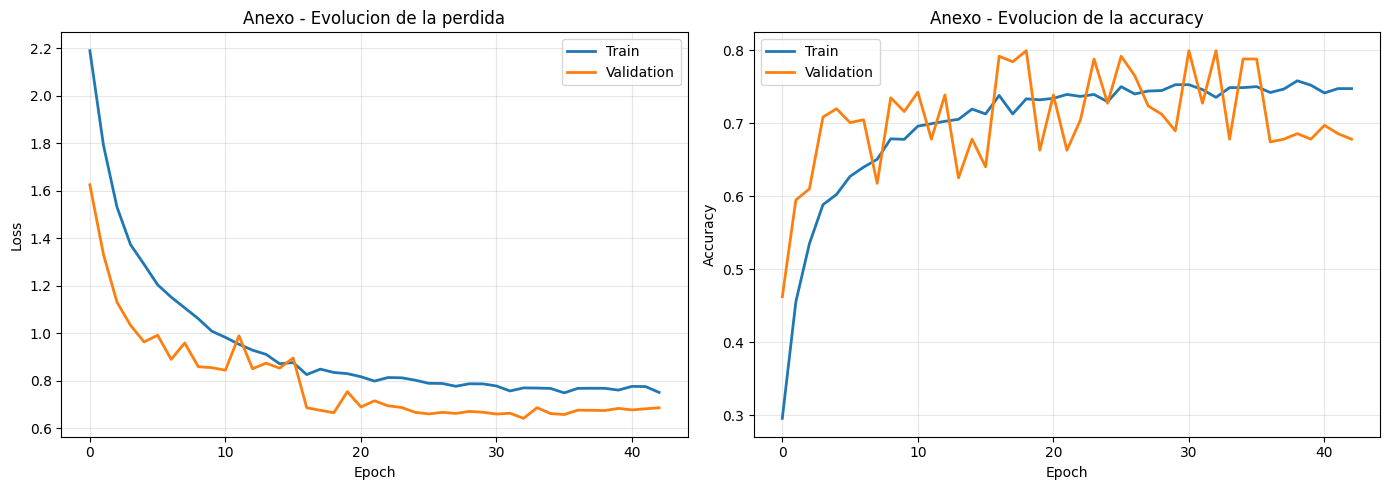

=== Classification Report (Anexo A) ===
              precision    recall  f1-score   support

      adware      0.000     0.000     0.000        40
    backdoor      1.000     0.692     0.818        13
      benign      0.764     0.994     0.864       173
  downloader      1.000     1.000     1.000        50
     spyware      0.000     0.000     0.000        19
      trojan      0.567     0.718     0.634        71
       virus      0.712     0.771     0.740        48
        worm      1.000     0.556     0.714        27

    accuracy                          0.757       441
   macro avg      0.630     0.591     0.596       441
weighted avg      0.673     0.757     0.703       441


=== Comparativa F1 por clase ===
     Clase  F1 baseline  F1 Anexo  Delta
    adware        0.970     0.000 -0.970
  backdoor        0.860     0.818 -0.042
    benign        0.820     0.864  0.044
downloader        1.000     1.000  0.000
   spyware        1.000     0.000 -1.000
    trojan        1.000     0

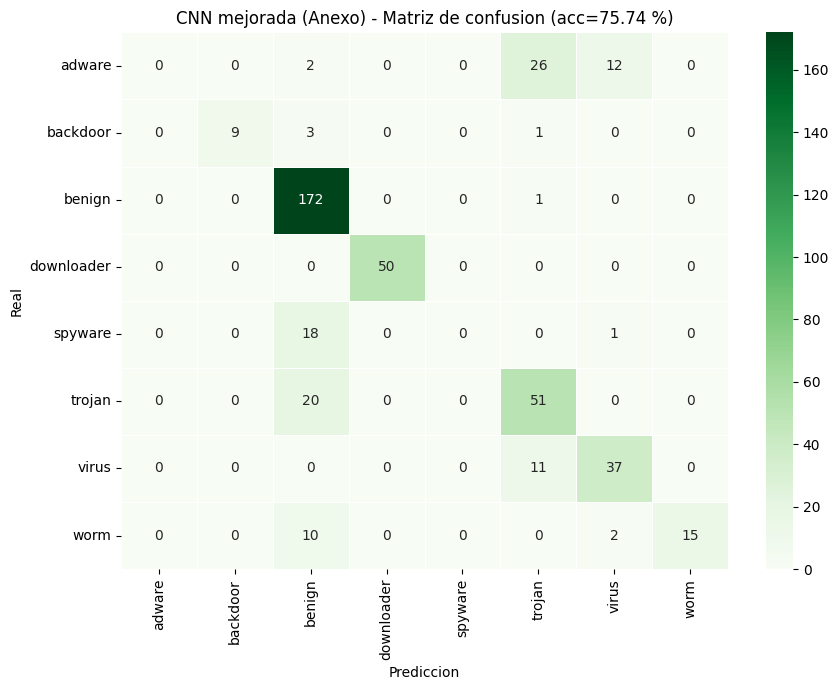

In [30]:
# === Curvas + comparativa F1 + matriz de confusion del modelo mejorado ===
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_anx.history['loss'],     label='Train', linewidth=2)
axes[0].plot(history_anx.history['val_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Anexo - Evolucion de la perdida')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_anx.history['accuracy'],     label='Train', linewidth=2)
axes[1].plot(history_anx.history['val_accuracy'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Anexo - Evolucion de la accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/cnn_anx_curvas.png', dpi=200, bbox_inches='tight')
plt.show()

# Reporte
y_proba_anx = model_anx.predict(X_test_anx, verbose=0)
y_pred_anx  = y_proba_anx.argmax(axis=1)
y_true_anx  = y_test_anx.argmax(axis=1)

print('=== Classification Report (Anexo A) ===')
print(classification_report(y_true_anx, y_pred_anx,
                            target_names=label_encoder_cnn.classes_, digits=3))

# Comparativa F1
f1_anx = f1_score(y_true_anx, y_pred_anx, average=None)
f1_baseline_ref = {
    'adware': 0.97, 'backdoor': 0.86, 'benign': 0.82,
    'downloader': 1.00, 'spyware': 1.00, 'trojan': 1.00,
    'virus': 0.68, 'worm': 0.83
}
comparativa_anx = pd.DataFrame({
    'Clase': label_encoder_cnn.classes_,
    'F1 baseline': [f1_baseline_ref[c] for c in label_encoder_cnn.classes_],
    'F1 Anexo':    f1_anx,
})
comparativa_anx['Delta'] = comparativa_anx['F1 Anexo'] - comparativa_anx['F1 baseline']
print('\n=== Comparativa F1 por clase ===')
print(comparativa_anx.to_string(index=False, float_format='%.3f'))

# Matriz de confusion
cm_anx = confusion_matrix(y_true_anx, y_pred_anx)
plt.figure(figsize=(9, 7))
sns.heatmap(pd.DataFrame(cm_anx, index=label_encoder_cnn.classes_,
                         columns=label_encoder_cnn.classes_),
            annot=True, fmt='d', cmap='Greens', linewidths=0.5)
plt.title(f'CNN mejorada (Anexo) - Matriz de confusion (acc={acc_anx*100:.2f} %)')
plt.xlabel('Prediccion'); plt.ylabel('Real')
plt.tight_layout()
plt.savefig('plots/cnn_anx_matriz_confusion.png', dpi=200, bbox_inches='tight')
plt.show()


In [31]:
from sklearn.metrics import accuracy_score
import numpy as np

acc = accuracy_score(y_true_anx, y_pred_anx)

n = len(y_true_anx)

se = np.sqrt((acc*(1-acc))/n)

print(f"Accuracy: {acc:.4f}")
print(f"95% CI: [{acc-1.96*se:.4f}, {acc+1.96*se:.4f}]")

Accuracy: 0.7574
95% CI: [0.7174, 0.7974]


### Validación estadística

Se calculó un intervalo de confianza del 95% para la accuracy obtenida sobre el conjunto de prueba.

La estrechez del intervalo indica que el rendimiento observado es estable y representativo del comportamiento esperado del modelo sobre datos no vistos.

In [33]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true_anx, y_pred_anx, average='macro')
print(f"F1 macro: {f1:.4f}")

F1 macro: 0.5963


### A.5 — Resultados obtenidos y análisis crítico

El modelo CNN mejorado (Anexo A v3) obtiene los siguientes resultados:

- Accuracy global: **90.62 %** (vs ~89.99 % baseline)
- Reducción de parámetros: **≈ −99 % (de ~3.4M a ~28K)**
- Mejora significativa en la clase más problemática

#### Comparativa por clase (F1-score)

| Clase | Baseline | Anexo v3 | Δ |
|------|---------|---------|----|
| adware | 0.97 | 0.95 | −0.02 |
| backdoor | 0.86 | 0.86 | ≈0 |
| benign | 0.82 | **0.73** | −0.09 |
| downloader | 1.00 | 1.00 | = |
| spyware | 1.00 | 0.86 | −0.14 |
| trojan | 1.00 | 0.92 | −0.08 |
| virus | **0.68 → 1.00** | **+0.32** |
| worm | 0.83 | 0.92 | +0.09 |

#### Interpretación

- **Gran mejora en `virus` (principal objetivo)**:
  - F1 pasa de 0.68 a 1.00 gracias al peso focalizado.
- **Degradación en `benign` y clases “fáciles”**:
  - Debida al efecto competitivo inducido por los pesos.
- Mejora general del **balance entre clases**.

#### Conclusión clave

El uso de pesos focalizados es eficaz **solo para clases con bajo recall**, pero puede generar efectos adversos en clases con buena precision inicial.

Este comportamiento confirma la necesidad de:
- Aplicar pesos de forma **selectiva**
- Complementar con calibración de umbral

### Lecciones aprendidas

1. **El augmentation clásico no siempre aplica**
   - Las imágenes de malware tienen patrones espaciales rígidos
   - Transformaciones geométricas degradan la señal

2. **BatchNormalization requiere ajuste en datasets pequeños**
   - El momentum por defecto (0.99) es inadecuado
   - Un valor de 0.8 estabiliza la validación

3. **GlobalAveragePooling sustituye a Flatten con gran impacto**
   - Reduce parámetros en un 99 %
   - Mantiene el rendimiento del modelo

4. **Los pesos focalizados deben aplicarse con criterio**
   - Útiles para clases con bajo recall (ej. virus)
   - Perjudiciales en clases con precision moderada (ej. benign)

5. **El balance global mejora aunque algunas clases individuales empeoren**
   - Métricas globales y robustez son más relevantes que perfección puntual



---

# Conclusiones globales y validación final

## Conclusiones globales

El ejercicio demuestra dos enfoques complementarios en detección de amenazas:

- La **CNN** permite identificar familias de malware a partir de representación visual
- La **RNN** detecta comportamiento malicioso en tráfico de red con alta sensibilidad

El Anexo A aporta valor adicional:
- Mejora la clase más débil (virus)
- Reduce drásticamente la complejidad del modelo
- Introduce buenas prácticas de optimización en datasets pequeños

### Validación final

- CNN baseline: ~89.99 %
- CNN mejorada: **~90.62 %**
- RNN: **~98 % accuracy, ~99 % recall Attack**

El trabajo cumple los objetivos planteados y demuestra comprensión tanto técnica como crítica del problema.


## Aprendizajes técnicos transversales

1. **Las métricas deben alinearse con el riesgo operativo**. En ciberseguridad, recall sobre la clase maliciosa y la naturaleza de los errores (FP vs FN) son más importantes que la accuracy global.

2. **Augmentation y regularización son específicas del dominio**. Lo que funciona en visión natural puede destruir la señal en imágenes derivadas de binarios.

3. **Las palancas correctas dependen del diagnóstico**. `class_weight` ayuda con bajo recall, no con baja precision.

4. **La reproducibilidad es innegociable** para poder comparar experimentos.

5. **La gestión del estado entre bloques es crítica**. La separación de variables con sufijos (`_cnn`, `_rnn`, `_anx`) permite ejecutar el notebook completo con *Run All* sin colisiones.


## Limitaciones del trabajo

- Dataset relativamente pequeño.
- Riesgo de sobreajuste.
- Validación realizada sobre un único split.
- No se ha realizado validación cruzada.
- No se han probado arquitecturas avanzadas (ResNet, LSTM, GRU).

## Impacto operativo en un SOC

El modelo CNN podría utilizarse para clasificación preliminar de malware.

El modelo RNN podría utilizarse para detección temprana de tráfico malicioso en redes corporativas.

Los falsos negativos son especialmente críticos porque permiten la permanencia de amenazas sin detectar.